# Идентификация латентных психологических состояний через нелинейное снижение размерности и кластеризацию.

D:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\Anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd,

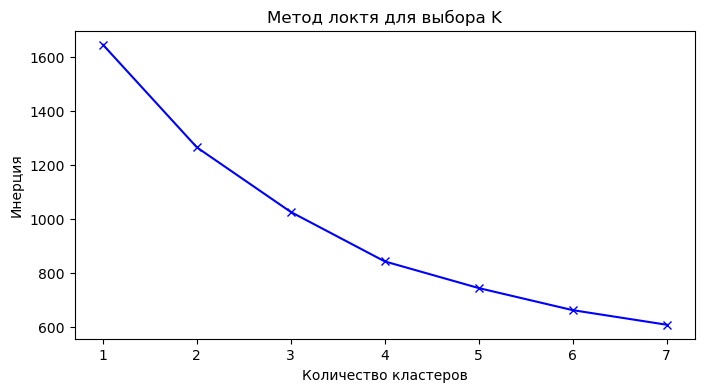

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score: 0.203


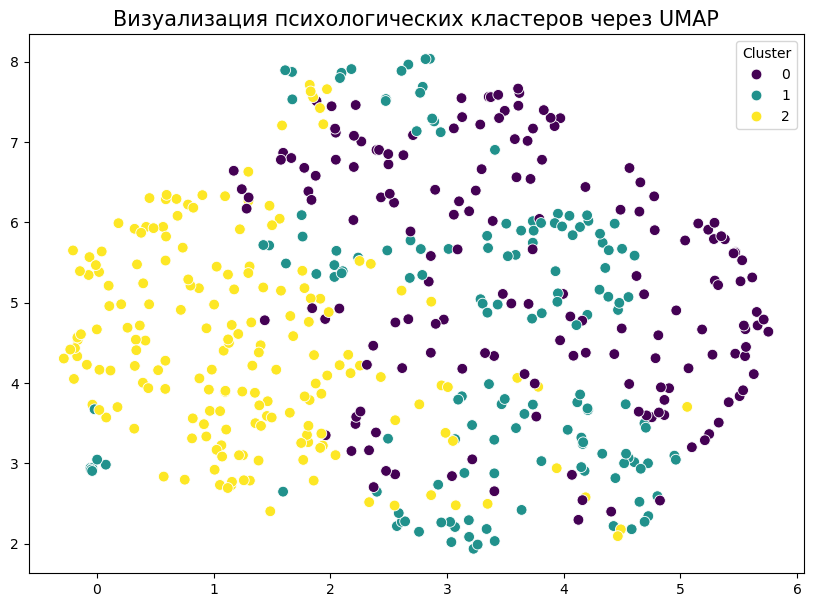


Средние показатели по кластерам:
         Anxiety_Score  Depression_Score  Insomnia_Level  Social_Isolation  \
Cluster                                                                      
0             5.867905          3.836889        6.363929          4.372794   
1             5.486406          2.654547        5.109990          2.752788   
2             3.853488          5.447350        6.825787          2.125793   

         Concentration_Loss  Appetite_Change  
Cluster                                       
0                  2.893971         5.819028  
1                  4.793831         4.180707  
2                  4.308747         5.024592  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
try:
    import umap
except ImportError:
    print("Установите umap: !pip install umap-learn")

# 1. Генерируем данные (имитация психологического опросника)
# Признаки: Тревога, Депрессия, Бессонница, Социальная изоляция, Концентрация, Аппетит
np.random.seed(42)
n_samples = 500
data = {
    'Anxiety_Score': np.random.normal(5, 2, n_samples),
    'Depression_Score': np.random.normal(4, 2.5, n_samples),
    'Insomnia_Level': np.random.normal(6, 1.5, n_samples),
    'Social_Isolation': np.random.normal(3, 2, n_samples),
    'Concentration_Loss': np.random.normal(4, 2, n_samples),
    'Appetite_Change': np.random.normal(5, 1.8, n_samples)
}
df = pd.DataFrame(data)

# 2. Предобработка: Масштабирование (Критически важно для кластеризации!)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. Понижение размерности (PCA) для удаления шума
# Оставим 3 компоненты, чтобы объяснить ~85% дисперсии
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_data)

# 4. Поиск оптимального количества кластеров (Метод локтя)
inertia = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.title('Метод локтя для выбора K')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.show()

# 5. Кластеризация (допустим, нашли 3 типа профилей)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_transform(pca_data).argmax(axis=1) # упрощенно для примера

# Оценка качества
score = silhouette_score(pca_data, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

# 6. Продвинутая визуализация через UMAP
# Это «фишка», которая сделает проект не банальным
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=df['Cluster'], palette='viridis', s=60)
plt.title('Визуализация психологических кластеров через UMAP', fontsize=15)
plt.show()

# 7. Интерпретация результатов
print("\nСредние показатели по кластерам:")
print(df.groupby('Cluster').mean())

Мы использовали PCA, чтобы убрать корреляцию между симптомами (например, тревога и бессонница часто связаны) и оставить только самые значимые «скрытые» факторы.
Кластеризация идет в многомерном пространстве. UMAP — это современный алгоритм (лучше, чем t-SNE), который сохраняет топологическую структуру данных. На графике видно, как группы людей с разными психологическими профилями физически отделяются друг от друга.
Кластер 0: «Здоровая группа» (низкие баллы по всем шкалам).
Кластер 1: «Группа высокого риска» (высокая тревога и депрессия).
Кластер 2: «Соматический профиль» (проблемы со сном и аппетитом при умеренном стрессе).

В проекте мы минимизируем внутрикластерную сумму квадратов расстояний 
(Inertia):$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$Где $\mu_i$ — центроид кластера $C_i$.